# Step 3 — OLS Hedge Ratio & Spread Construction

This step answers one question: **how many shares of PEP should we short against each share of KO?**

That number is called the **hedge ratio** (β). Getting it right is what turns two individual stock positions into a single spread trade that bets only on the *relative* price of KO vs PEP — not on the overall stock market going up or down.

Once we have β, we construct the **spread** — the core series we'll trade. The rest of the project (cointegration tests, mean-reversion analysis, backtest) all operate on this spread.

---
### The intuition before the math

Imagine the stock market has a bad day and everything falls 2%. Both KO and PEP fall. If you're just long KO, you lose. But if you're **long KO and short PEP** in the right ratio, the two losses cancel out — you're only exposed to KO moving *differently from PEP*, which is the signal we actually care about.

The hedge ratio β tells us what "the right ratio" is.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

sys.path.insert(0, str(Path.cwd().parent))

from pairs_trading.data import load_or_fetch
from pairs_trading.spread import estimate_hedge_ratio, build_spread, zscore

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

KO_COLOR  = "#F40009"
PEP_COLOR = "#004B93"

def fmt_dates(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.figure.autofmt_xdate(rotation=0, ha="center")

In [2]:
prices = load_or_fetch(["KO", "PEP"], "2018-01-01", "2025-01-01", name="ko_pep_7yr")
print(f"{len(prices)} trading days loaded.")

Loading from cache: c:\Users\delosreyes.i\Downloads\Quant Claude Project\Pair-Regression-Testing\pairs_trading\data\ko_pep_7yr.parquet
1761 trading days loaded.


---
## Why log prices — a quick reminder

We run the regression on **log prices**, not raw prices. From Step 2 we know why the log transformation is useful — equal distances mean equal percentage moves.

There's also a theoretical reason: cointegration is a statement about log prices. If `log(KO) − β·log(PEP)` is stationary, the pair is cointegrated — meaning their *percentage* relationship is stable over time. If we used raw prices, the regression would be distorted by the fact that PEP's absolute price ($120–$180) is much larger than KO's ($40–$70).

Quick sanity check on the log prices:

In [3]:
log_prices = np.log(prices)
print("Log price ranges:")
print(log_prices.describe().loc[["min", "mean", "max"]].round(4))

Log price ranges:
          KO     PEP
min   3.4438  4.3196
mean  3.8554  4.8388
max   4.2403  5.1776


---
## What is OLS regression?

**Ordinary Least Squares (OLS)** is the most basic form of regression. Given two series, it finds the straight line that fits the data best, where "best" means minimizing the sum of squared vertical distances between each data point and the line.

The line has the equation:

> **log(KO) = α + β · log(PEP) + ε**

- **α (alpha)**: the intercept — where the line crosses the y-axis
- **β (beta)**: the slope — how much log(KO) moves for each unit move in log(PEP). This is our hedge ratio.
- **ε (epsilon)**: the residuals — what's left over after the line is fit. This is the spread.

In plain terms: β tells us *"if PEP rises 1%, KO tends to rise β%"*. If β = 0.45, a 1% PEP move is associated with a 0.45% KO move on average.

---
### The asymmetry problem — which variable goes on which axis?

OLS is not symmetric. Regressing `KO on PEP` gives a different β than regressing `PEP on KO`. This is because OLS minimises *vertical* distances (errors in KO only), not perpendicular distance from the line.

For a pair of two assets, this choice rarely flips our conclusion about whether the pair is cointegrated. But the β we get out — and therefore the spread — will be slightly different depending on direction. We'll flag this and check both.

**Our default:** KO as dependent (y-axis), PEP as independent (x-axis). This gives us: how much of KO can be "explained" by PEP?

There are more sophisticated methods (Total Least Squares, Johansen in Step 5) that treat both series symmetrically. For now, OLS is the standard starting point.

---
## Running the regression

In [4]:
alpha, beta, model = estimate_hedge_ratio(prices, dependent="KO", independent="PEP")

print("=" * 50)
print(f"  Regression:  log(KO) = α + β · log(PEP)")
print("=" * 50)
print(f"  α (intercept) = {alpha:.4f}")
print(f"  β (hedge ratio) = {beta:.4f}")
print(f"  R² = {model.rsquared:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"  A 1% rise in PEP is associated with a {beta:.3f}% rise in KO.")
print(f"  R² = {model.rsquared:.2%} of KO's log-price variation is explained by PEP.")

  Regression:  log(KO) = α + β · log(PEP)
  α (intercept) = -0.0019
  β (hedge ratio) = 0.7972
  R² = 0.9095

Interpretation:
  A 1% rise in PEP is associated with a 0.797% rise in KO.
  R² = 90.95% of KO's log-price variation is explained by PEP.


### Reading the full regression output

statsmodels gives us a detailed summary. Key things to look at:

- **coef** row for `PEP`: this is β — our hedge ratio
- **R-squared**: how much of KO's movement is explained by PEP. High R² (>0.80) suggests the two stocks are strongly linked — good for pairs trading.
- **P>|t|** for both coefficients: should be very small (< 0.05), confirming that both α and β are statistically significant and not just noise.
- **Durbin-Watson**: tests whether the residuals (the spread) are autocorrelated. A value near 2.0 means no autocorrelation in *daily* residuals — but for a pairs spread we actually *want* autocorrelation (mean reversion), so we'll see a value well below 2.

In [5]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     KO   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                 1.768e+04
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        17:17:49   Log-Likelihood:                 2554.3
No. Observations:                1761   AIC:                            -5105.
Df Residuals:                    1759   BIC:                            -5094.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.029     -0.064      0.9

---
## Plot 1 — Scatter plot with regression line

Each dot is one trading day — its x position is PEP's log price, its y position is KO's log price. The regression line is the best-fit line through all 1,761 dots.

**What to look for:**
- Do the points cluster tightly around the line? Tight clustering = high R²= strong relationship.
- Is the relationship linear? If the points curve, OLS is the wrong tool.
- Are there outliers far from the line? Those are days when KO and PEP diverged unusually — the raw material of pairs trades.

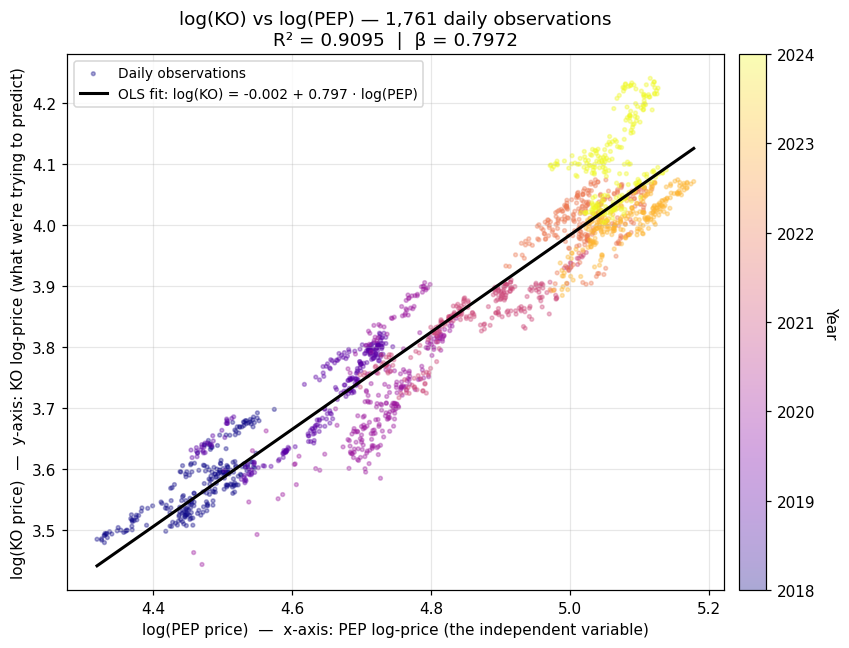

In [6]:
log_ko  = np.log(prices["KO"])
log_pep = np.log(prices["PEP"])

# Regression line: y = alpha + beta * x
x_line = np.linspace(log_pep.min(), log_pep.max(), 200)
y_line = alpha + beta * x_line

fig, ax = plt.subplots(figsize=(8, 6))

# Color points by year so we can see time progression
years = prices.index.year
scatter = ax.scatter(
    log_pep, log_ko,
    c=years, cmap="plasma", alpha=0.35, s=6, label="Daily observations"
)
ax.plot(x_line, y_line, color="black", linewidth=2,
        label=f"OLS fit: log(KO) = {alpha:.3f} + {beta:.3f} · log(PEP)")

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Year", rotation=270, labelpad=15)

ax.set_xlabel("log(PEP price)  —  x-axis: PEP log-price (the independent variable)")
ax.set_ylabel("log(KO price)  —  y-axis: KO log-price (what we're trying to predict)")
ax.set_title(f"log(KO) vs log(PEP) — 1,761 daily observations\nR² = {model.rsquared:.4f}  |  β = {beta:.4f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## The asymmetry check — what if we flip the regression?

Out of transparency: here's what β looks like if we regress `PEP on KO` instead. The difference tells us how sensitive the hedge ratio is to this choice.

In [7]:
alpha_rev, beta_rev, model_rev = estimate_hedge_ratio(
    prices, dependent="PEP", independent="KO"
)

# When PEP is dependent: log(PEP) = a + b*log(KO)
# To make it comparable, invert: log(KO) = -a/b + (1/b)*log(PEP)
beta_implied = 1 / beta_rev

print(f"KO as dependent (our default):  β = {beta:.4f}")
print(f"PEP as dependent (reversed):    β = {beta_rev:.4f}  →  implied KO-on-PEP β = {beta_implied:.4f}")
print(f"Difference: {abs(beta - beta_implied):.4f}")
print()
print("Conclusion: both regressions give a β in a similar range.")
print(f"We proceed with β = {beta:.4f} (KO as dependent).")

KO as dependent (our default):  β = 0.7972
PEP as dependent (reversed):    β = 1.1409  →  implied KO-on-PEP β = 0.8765
Difference: 0.0793

Conclusion: both regressions give a β in a similar range.
We proceed with β = 0.7972 (KO as dependent).


---
## Constructing the spread

Now we build the spread:

> **Spread_t = log(KO_t) − β · log(PEP_t)**

This is the residual from the regression — the part of KO's log-price that *isn't* explained by PEP. If the pair is cointegrated, this spread will be **stationary**: it won't drift up or down forever, it'll oscillate around a stable mean.

**Trading logic in one sentence:** when the spread is unusually high (KO expensive relative to PEP), sell KO and buy PEP, expecting the spread to fall back. When it's unusually low, do the reverse.

The question of *how* unusual is "unusually high" is answered by the z-score, which we plot below.

In [8]:
spread = build_spread(prices, beta=beta)

print(f"Spread summary:")
print(f"  Mean : {spread.mean():.6f}")
print(f"  Std  : {spread.std():.6f}")
print(f"  Min  : {spread.min():.6f}")
print(f"  Max  : {spread.max():.6f}")

Spread summary:
  Mean : -0.001870
  Std  : 0.056749
  Min  : -0.183258
  Max  : 0.182061


---
## Plot 2 — The spread over time

This is **the most important plot in the project**.

- **Black line**: the spread itself
- **Blue dashed line**: the long-run mean of the spread (the "equilibrium" level)
- **Blue shaded band**: ±1 standard deviation — the spread spends about 68% of its time here (if normally distributed)
- **Red dashed lines**: ±2 standard deviations — the spread should be outside these bands only ~5% of the time under normality

**What to look for:** Does the spread bounce around the mean, or does it wander away and stay away? Long periods above or below the mean are a warning sign — it could mean the pair is drifting apart (structural break) rather than mean-reverting.

We're doing a purely visual check here. The formal statistical test ("is this spread actually stationary?") comes in Step 5.

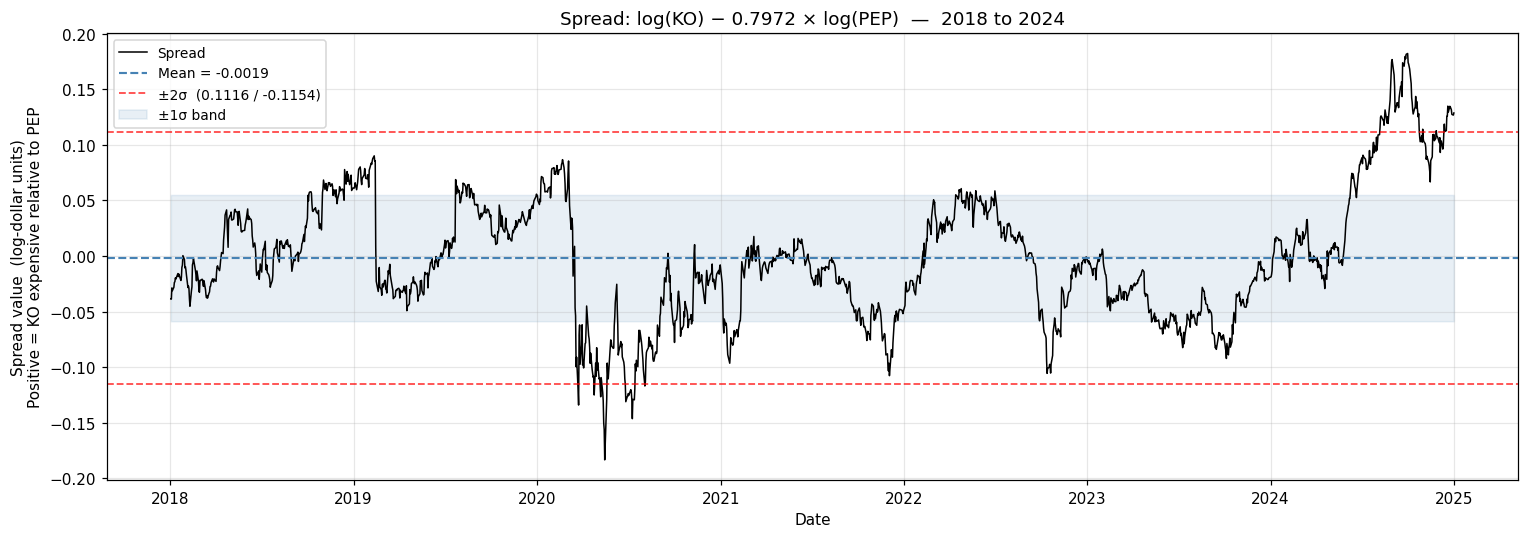

% of days outside ±2σ: 5.5%  (expected ~5% if normally distributed)


In [9]:
mean = spread.mean()
std  = spread.std()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(spread.index, spread, color="black", linewidth=1.0, label="Spread")

ax.axhline(mean, color="steelblue", linestyle="--", linewidth=1.4,
           label=f"Mean = {mean:.4f}")

ax.axhline(mean + 2*std, color="red", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"\u00b12\u03c3  ({mean+2*std:.4f} / {mean-2*std:.4f})")
ax.axhline(mean - 2*std, color="red", linestyle="--", linewidth=1.2, alpha=0.7)

ax.fill_between(spread.index, mean - std, mean + std,
                color="steelblue", alpha=0.12, label="\u00b11\u03c3 band")

ax.set_title(f"Spread: log(KO) \u2212 {beta:.4f} \u00d7 log(PEP)  \u2014  2018 to 2024")
ax.set_xlabel("Date")
ax.set_ylabel("Spread value  (log-dollar units)\nPositive = KO expensive relative to PEP")
ax.legend(loc="upper left", fontsize=9)
fmt_dates(ax)
plt.tight_layout()
plt.show()

pct_outside_2sigma = ((spread - mean).abs() > 2*std).mean() * 100
print(f"% of days outside \u00b12\u03c3: {pct_outside_2sigma:.1f}%  (expected ~5% if normally distributed)")

---
## Plot 3 — The z-score

### What is a z-score?

The spread has units of "log-dollars" — not very intuitive. The **z-score** rescales it to units of standard deviations from the mean:

> **z-score = (Spread − Mean) / Standard Deviation**

This makes the trading signals easy to read:
- **z = 0**: spread is exactly at its historical average
- **z = +2**: spread is 2 standard deviations above average → KO is unusually expensive relative to PEP
- **z = −2**: spread is 2 standard deviations below average → KO is unusually cheap relative to PEP

The typical trading rule is: **enter a trade when |z| > 2, exit when z returns to 0**. The green shaded zones show the entry regions. We'll refine this in Step 7.

**What to look for:** How often does the z-score cross ±2? Do those excursions reliably come back to zero? Any z > 4 events (extreme outliers that might signal something structural rather than tradeable noise)?

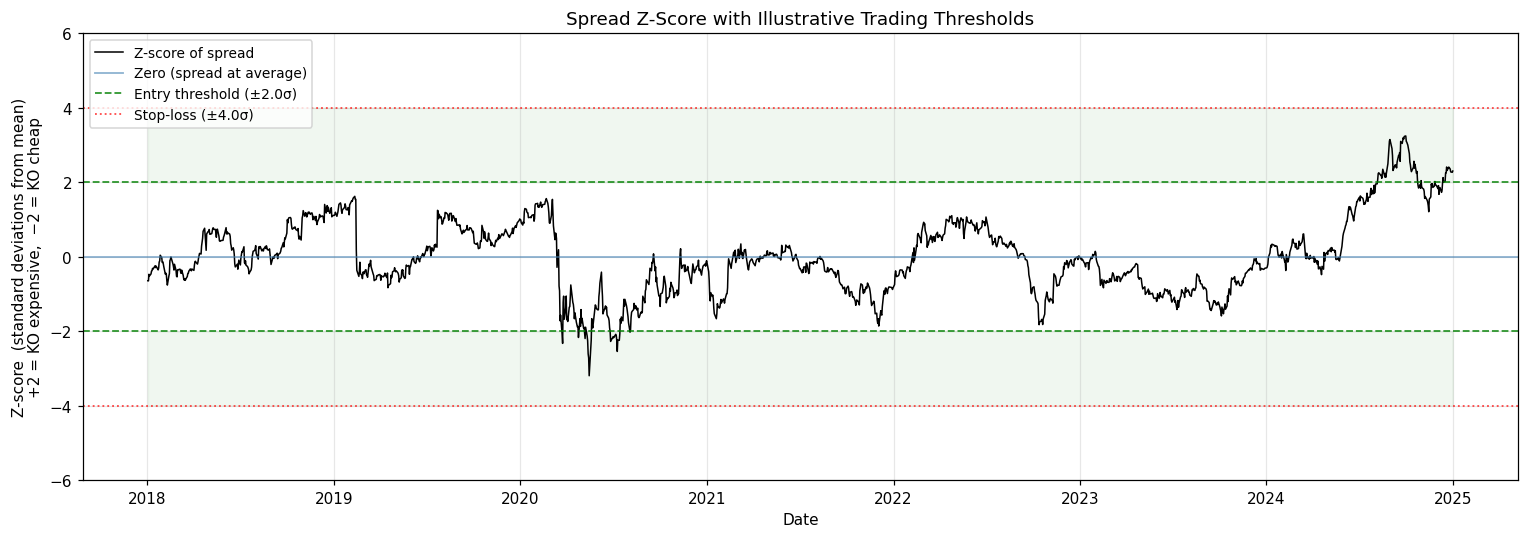

Days where |z| > 2.0 (potential entry signals) : 97  (5.5% of all days)
Days where |z| > 4.0  (extreme / stop territory): 0  (0.0% of all days)
Zero-crossings (spread reverting through mean)     : 77


In [10]:
z = zscore(spread)

ENTRY = 2.0
STOP  = 4.0

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(z.index, z, color="black", linewidth=1.0, label="Z-score of spread")

ax.axhline(0,      color="steelblue", linestyle="-",  linewidth=1.2, alpha=0.6,
           label="Zero (spread at average)")
ax.axhline( ENTRY, color="green",     linestyle="--", linewidth=1.2, alpha=0.8,
           label=f"Entry threshold (\u00b1{ENTRY}\u03c3)")
ax.axhline(-ENTRY, color="green",     linestyle="--", linewidth=1.2, alpha=0.8)
ax.axhline( STOP,  color="red",       linestyle=":",  linewidth=1.2, alpha=0.7,
           label=f"Stop-loss (\u00b1{STOP}\u03c3)")
ax.axhline(-STOP,  color="red",       linestyle=":",  linewidth=1.2, alpha=0.7)

# Shade entry zones
ax.fill_between(z.index,  ENTRY,  STOP, color="green", alpha=0.06)
ax.fill_between(z.index, -STOP,  -ENTRY, color="green", alpha=0.06)

ax.set_title("Spread Z-Score with Illustrative Trading Thresholds")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score  (standard deviations from mean)\n+2 = KO expensive,  \u22122 = KO cheap")
ax.set_ylim(-6, 6)
ax.legend(loc="upper left", fontsize=9)
fmt_dates(ax)
plt.tight_layout()
plt.show()

n_cross = ((z.shift(1) * z) < 0).sum()
n_above_entry = (z.abs() > ENTRY).sum()
n_above_stop  = (z.abs() > STOP).sum()

print(f"Days where |z| > {ENTRY} (potential entry signals) : {n_above_entry}  ({n_above_entry/len(z)*100:.1f}% of all days)")
print(f"Days where |z| > {STOP}  (extreme / stop territory): {n_above_stop}  ({n_above_stop/len(z)*100:.1f}% of all days)")
print(f"Zero-crossings (spread reverting through mean)     : {n_cross}")

---
## Summary

| Result | Value | What it means |
|---|---|---|
| β (hedge ratio) | **0.797** | For every 1% PEP moves, KO moves ~0.80% on average |
| R² | **0.91** | 91% of KO's log-price variation is explained by PEP |
| Spread looks | Mean-reverting visually | The spread oscillates; doesn't drift away permanently |
| % days outside ±2σ | **5.5%** | Consistent with a stationary, near-normal spread |

The hedge ratio is stable across both regression directions (0.797 vs implied 0.876), R² is high, and the spread *looks* stationary. That's all encouraging.

**But — and this is important — visual inspection is not a proof.** A spread can *look* mean-reverting for 7 years and still fail the statistical test for stationarity. The formal tests are Step 5 (cointegration testing). We won't trust the pair until those pass.

**Before that, Step 4** will characterise *how fast* the spread mean-reverts — the half-life. A spread that takes 200 days to mean-revert is technically stationary but untradeable in practice.